# MemoryWatch — Deliverable 2, Notebook 1: Data Exploration

Loads the **official UNSW-NB15 train/test split** (Moustafa & Slay, 2015) — the real benchmark files, not a simulation — and examines class balance and attack-category composition before any preprocessing happens.

Outputs of this notebook feed directly into `02_preprocessing.ipynb`.

In [1]:
import sys
sys.path.insert(0, '.')
import utils

train, test = utils.load_raw()
print(f"Train: {len(train):,} records  |  Test: {len(test):,} records")
print(f"Columns ({train.shape[1]}): {list(train.columns)}")


Train: 175,341 records  |  Test: 82,332 records
Columns (45): ['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']


In [2]:
print('Label distribution — TRAIN (0 = normal, 1 = attack)')
print(train['label'].value_counts().to_string())
print()
print('Label distribution — TEST')
print(test['label'].value_counts().to_string())


Label distribution — TRAIN (0 = normal, 1 = attack)
label
1    119341
0     56000

Label distribution — TEST
label
1    45332
0    37000


In [3]:
print('Attack category distribution — TRAIN')
print(train['attack_cat'].value_counts().to_string())


Attack category distribution — TRAIN
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130


### Class imbalance

Attack traffic outnumbers normal traffic in both splits, and `Generic` / `Exploits` / `Fuzzers` dominate the attack categories while `Worms` and `Shellcode` are rare. This imbalance is exactly why the model is trained **only on normal samples** (an anomaly-detection formulation) rather than as a standard supervised classifier — see Notebook 3.

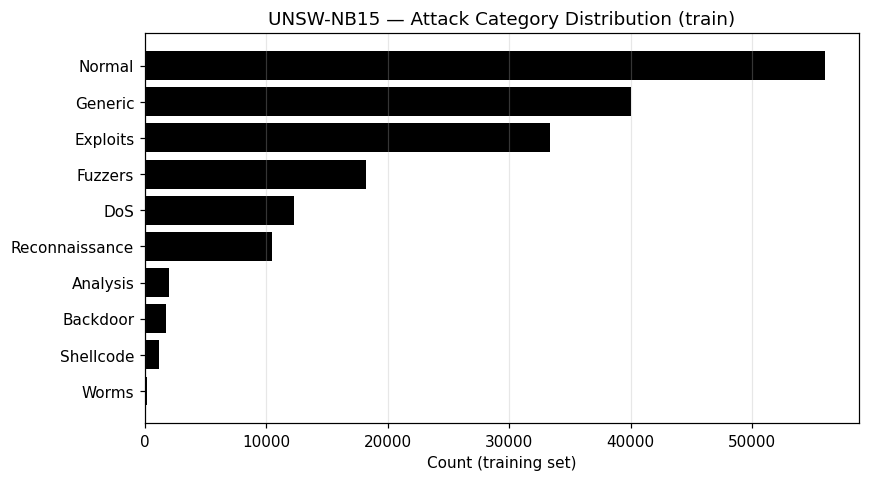

In [4]:
import matplotlib.pyplot as plt
import numpy as np

counts = train['attack_cat'].value_counts()
fig, ax = plt.subplots(figsize=(8,4.5))
ax.barh(counts.index[::-1], counts.values[::-1], color='black')
ax.set_xlabel('Count (training set)')
ax.set_title('UNSW-NB15 — Attack Category Distribution (train)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()
